/tmp/ipykernel_2636/1200919330.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data =yf.download("TCS.NS",period='5y',interval="1wk")
[*********************100%***********************]  1 of 1 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2021-05-10 to 2026-05-11
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   262 non-null    float64
 1   (High, TCS.NS)    262 non-null    float64
 2   (Low, TCS.NS)     262 non-null    float64
 3   (Open, TCS.NS)    262 non-null    float64
 4   (Volume, TCS.NS)  262 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 12.3 KB


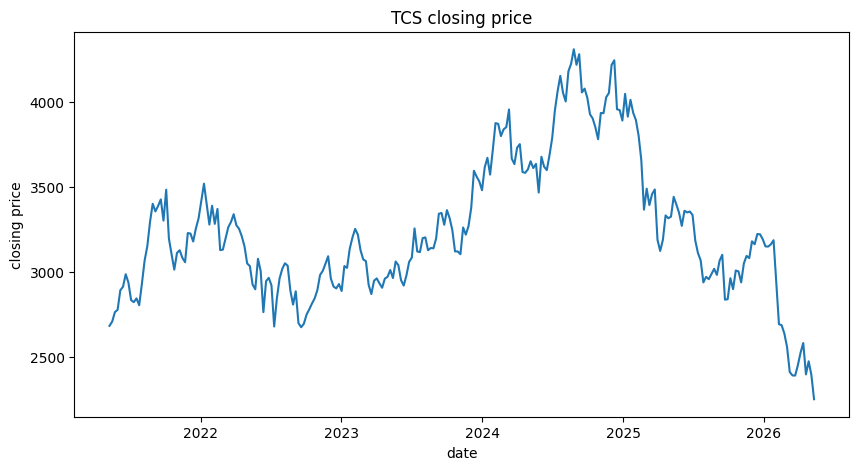

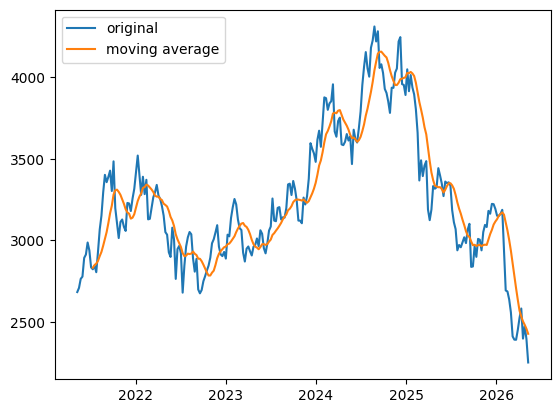

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


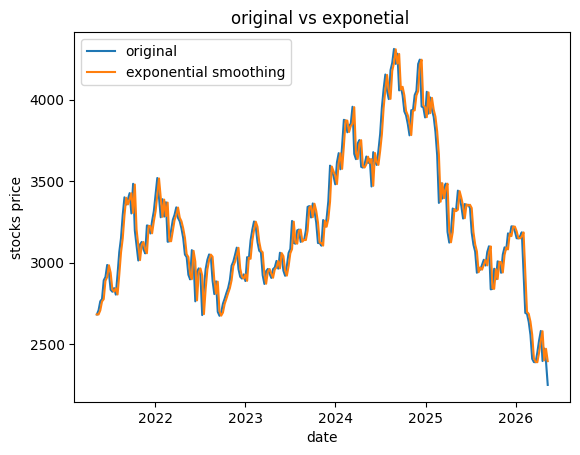

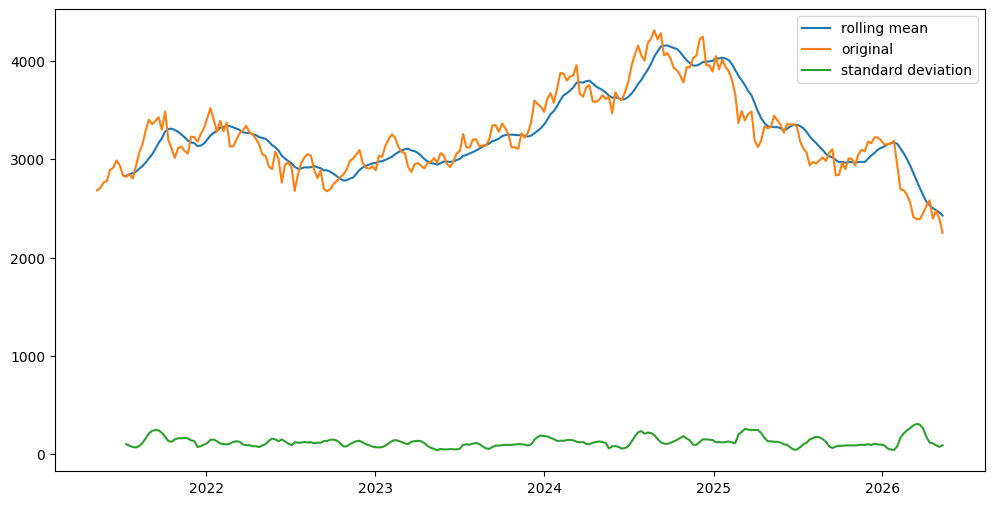

-1.4505652034563938
0.5578090883174509
-16.388614484039582
2.7077787919384224e-29


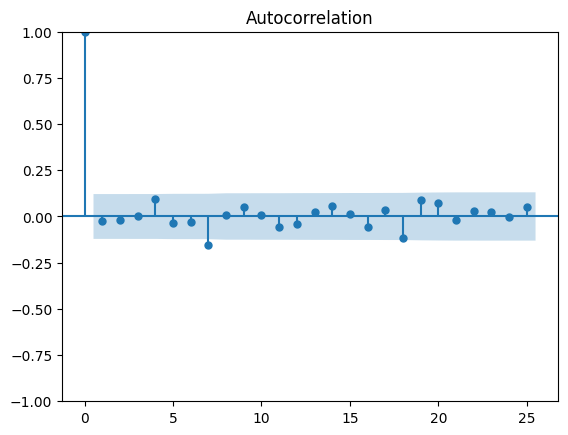

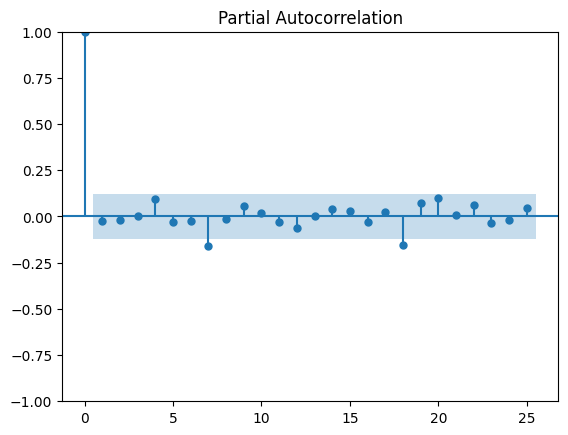

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


2026-05-18    2254.486907
2026-05-25    2255.192774
2026-06-01    2255.317745
2026-06-08    2255.339871
2026-06-15    2255.343788
Freq: W-MON, Name: predicted_mean, dtype: float64


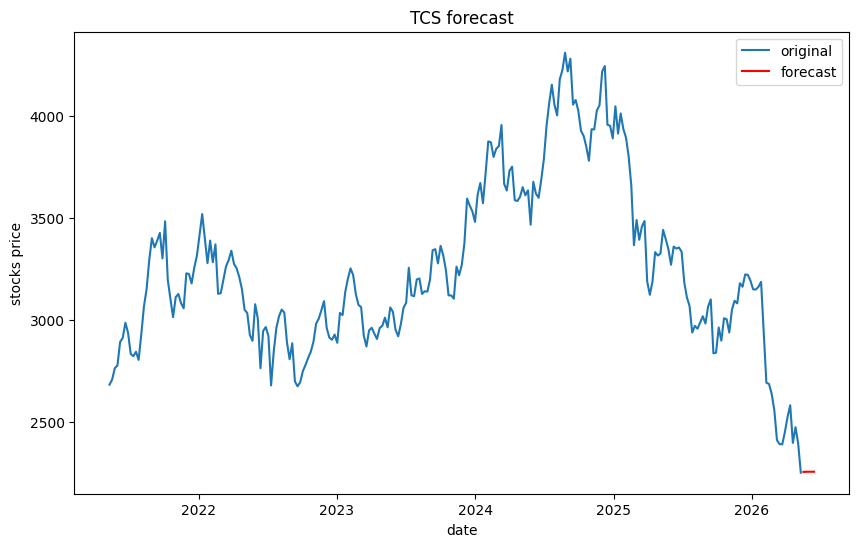

130.15206737895255
77.2861744109316


Price,Close,High,Low,Open,Volume,MA,st
Date,,,,,,,
2021-05-10,2682.502930,2723.819540,2672.393546,2723.819540,2043935,NaN,NaN
2021-05-17,2707.996826,2746.236677,2668.877898,2685.580362,10989634,NaN,NaN
2021-05-24,2763.466553,2828.650027,2700.524553,2708.875785,13141112,NaN,NaN
2021-05-31,2777.116455,2800.614370,2751.719366,2782.637561,8388084,NaN,NaN
2021-06-07,2892.000000,2923.094831,2768.150573,2778.220986,12172081,NaN,NaN


In [ ]:
#importing libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error as mae

#plotting stocks prices
data =yf.download("TCS.NS",period='5y',interval="1wk")
data.head()
data.shape
data.info()
data.isnull().sum()
data=data.dropna()
plt.figure(figsize=(10,5))
plt.plot(data["Close"])
plt.title("TCS closing price")
plt.xlabel("date")
plt.ylabel("closing price")
plt.show()
data.columns=data.columns.droplevel(1)
data.columns
data['MA']=data['Close'].rolling(window=10).mean()

#applying moving average
plt.plot(data['Close'],label='original')
plt.plot(data['MA'],label='moving average')
plt.legend()
plt.show()

#applying exponential smoothing
exponential=ExponentialSmoothing(data['Close'])
smoothing=exponential.fit()
plt.plot(data['Close'],label='original')
plt.plot(smoothing.fittedvalues,label='exponential smoothing')
plt.title('original vs exponetial ')
plt.xlabel('date')
plt.ylabel('stocks price')
plt.legend()
plt.show()

# standard deviation
data['st']=data['Close'].rolling(window=10).std()
plt.figure(figsize=(12,6))
plt.plot(data ['MA'],label='rolling mean')
plt.plot(data['Close'],label='original')
plt.plot(data['st'],label='standard deviation')
plt.legend()
plt.show()

#checking stationarity
result=adfuller(data['Close'])
print(result[0])
print(result[1])

#differencing
diff=data['Close'].diff()
diff=diff.dropna()
result2=adfuller(diff)
print(result2[0])
print(result2[1])

plot_acf(diff)
plt.show()
plot_pacf(diff)
plt.show()

#applying ARIMA model
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(data['Close'],order=(1,1,1))
model_fit=model.fit()
forecast=model_fit.forecast(steps=5)
print(forecast)

plt.figure(figsize=(10,6))
plt.plot(data['Close'] ,label='original')
plt.plot(forecast,label='forecast',color='red')
plt.title('TCS forecast')
plt.xlabel('date')
plt.ylabel('stocks price')
plt.legend()
plt.show()

#error analysis
temp=data[['Close','MA']].dropna()
ma_error=mae(temp['Close'],temp['MA'])
print(ma_error)
es_error=mae(data['Close'].dropna(),smoothing.fittedvalues)
print(es_error)

data.head()

